In [1]:
import pandas as pd
df=pd.read_csv("california_housing_train.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [2]:
df.shape

(17000, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [4]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [5]:
df.corr()['population']

longitude             0.101674
latitude             -0.111261
housing_median_age   -0.295890
total_rooms           0.860170
total_bedrooms        0.881169
population            1.000000
households            0.909247
median_income        -0.000638
median_house_value   -0.027850
Name: population, dtype: float64

Text(0.5, 1.0, 'Simple Linear Regression (population vs Bedroom)')

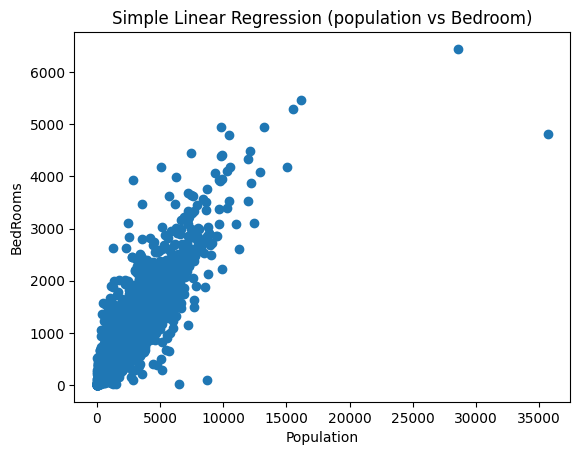

In [6]:
df['population']
df['total_bedrooms']
import matplotlib.pyplot as plt
plt.scatter(df['population'],df['total_bedrooms'])
plt.xlabel("Population")
plt.ylabel("BedRooms")
plt.title("Simple Linear Regression (population vs Bedroom)")

In [7]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(df[['population']],df['total_bedrooms'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
model_pred = model.predict(df[['population']])
model_pred=model_pred.astype(int)
model_pred

array([405, 442, 184, ..., 479, 496, 337], shape=(17000,))

Text(0.5, 1.0, 'Simple Linear Regression (population vs Bedroom)')

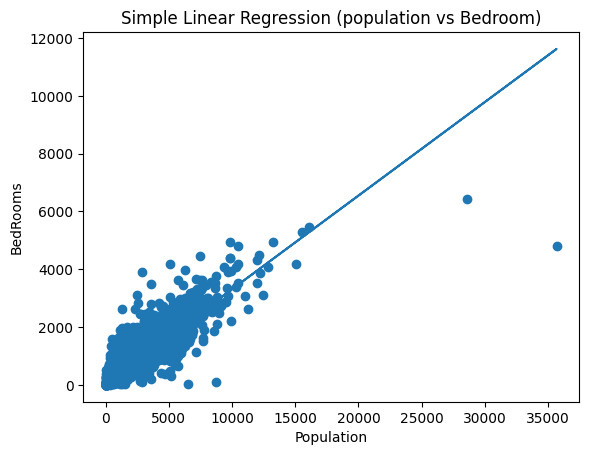

In [9]:
plt.scatter(df['population'],df['total_bedrooms'])
plt.plot(df[['population']],model_pred)
plt.xlabel("Population")
plt.ylabel("BedRooms")
plt.title("Simple Linear Regression (population vs Bedroom)")

In [10]:
dframe = pd.DataFrame({'population':df['population'].astype(int),
                       'Actual_Bedrooms(Actual)':df['total_bedrooms'].astype(int),
                       'Model_Bedrooms(predicted)':model_pred})
dframe.head()

,population,Actual_Bedrooms(Actual),Model_Bedrooms(predicted)
0,1015,1283,405
1,1129,1901,442
2,333,174,184
3,515,337,243
4,624,326,278


In [11]:
from sklearn.metrics import r2_score
reg_acc=r2_score(df['total_bedrooms'],model_pred)
print("r2 score(model)",reg_acc)

r2 score(model) 0.7764557341417537


In [12]:
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.metrics import mean_squared_error
reg_acc=r2_score(df['total_bedrooms'],model_pred)
print("r2 score(model)",reg_acc)

r2 score(model) 0.7764557341417537


In [13]:
mse=mean_squared_error(df['total_bedrooms'],model_pred)
mae=mean_absolute_error(df['total_bedrooms'],model_pred)
print(f"mean square error:{mse:.2f}")
print(f"mean absolute error:{mae:.2f}")


mean square error:39712.94
mean absolute error:118.36


In [14]:
import math
rmse=math.sqrt(mse)
rmse

199.2810520493164

In [15]:
import math
rmse=math.sqrt(mse)
print(f"Root mean square error:{rmse:.2f}")


Root mean square error:199.28


In [16]:
 #slope and intercept(y = mx + c)
print("Intercept for my model:(c):,",model.intercept_)
print("slope(coefficient):",model.coef_[0])

Intercept for my model:(c):, 76.84197820308827
slope(coefficient): 0.32357112283793565


In [19]:
print(f"Intercept for my model:(c):,{model.intercept_:.2f}")
print(f"slope(coefficient):{model.coef_[0]:.2f}")

Intercept for my model:(c):,76.84
slope(coefficient):0.32


In [21]:
import numpy as np
population = np.array([300]).reshape(1,-1)
new_bedrooms=model.predict(population)
print(f"no of bedrooms needed for {population}:{new_bedrooms.astype(int)}")

no of bedrooms needed for [[300]]:[173]


C:\Users\harshitha y\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
arr=np.array([1,2,3])
print(arr.ndim)
print(arr.shape)

1
(3,)


In [25]:
arr=arr.reshape([1,-1])
print(arr.ndim)
print(arr.shape)

2
(1, 2)


In [26]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


MULTIPLE LINEAR REGRESSION

In [18]:
#importing all necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score

In [19]:
home=pd.read_csv("california_housing_train.csv")
home.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [20]:
#check the missing values
home.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [21]:
X=home.drop('median_house_value',axis=1)


In [22]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250


In [23]:
X.shape

(17000, 8)

In [26]:
home.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [27]:
home.shape

(17000, 9)

In [24]:
y=home['median_house_value']
y.shape

(17000,)

In [28]:
y.head()

0    66900.0
1    80100.0
2    85700.0
3    73400.0
4    65500.0
Name: median_house_value, dtype: float64

In [29]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [30]:
x_train.shape,x_test.shape

((13600, 8), (3400, 8))

In [31]:
X.shape

(17000, 8)

In [35]:
#Feature Scaling :ScandardScaler()
from sklearn.preprocessing import StandardScaler
scale=StandardScaler() #object
x_train_scaled=scale.fit_transform(x_train)
x_train_scaled

array([[ 0.74182975, -0.84715727, -0.52839839, ..., -0.1093373 ,
        -0.34660377,  2.44336202],
       [ 0.96140556, -0.99243346, -1.32221004, ...,  0.06388797,
        -0.02353959,  1.74194208],
       [ 1.23088496, -1.42826202, -0.92530422, ..., -0.92634004,
        -1.07870889,  0.66656067],
       ...,
       [ 0.70190687, -0.80029399,  0.74170025, ..., -0.57902769,
        -0.76346077, -0.47689942],
       [ 1.24086568, -1.43294835, -1.56035354, ...,  1.60395538,
         0.88312441, -0.40625469],
       [-1.42398618,  0.99925621,  1.85303657, ...,  0.43102211,
         0.12496572, -0.777493  ]], shape=(13600, 8))

In [36]:
x_train_scaled= pd.DataFrame(x_train_scaled,columns=X.columns)
x_train_scaled.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,0.741830,-0.847157,-0.528398,0.033111,-0.445165,-0.109337,-0.346604,2.443362
1,0.961406,-0.992433,-1.322210,0.451867,-0.008317,0.063888,-0.023540,1.741942
2,1.230885,-1.428262,-0.925304,-1.012397,-1.083819,-0.926340,-1.078709,0.666561
3,1.195952,-1.315790,0.424176,-0.167966,-0.390559,-0.354093,-0.317945,-0.124566
4,0.741830,-0.678449,0.582938,-0.103400,-0.345450,-0.186901,-0.229363,0.872891


In [37]:
x_test_scaled=scale.fit_transform(x_test)
x_test_scaled

array([[-0.6396086 ,  0.98333321, -1.54081879, ...,  0.94831502,
         1.08727131, -0.16937326],
       [ 0.71865479, -0.71851548,  1.88838318, ..., -0.24391615,
        -0.22717261,  2.20538143],
       [-0.23163205,  0.61599428, -0.9825766 , ...,  0.95105159,
         0.50364788, -0.73044948],
       ...,
       [-0.70428781,  0.92288503, -0.74332996, ..., -0.69544976,
        -1.19040952, -1.55673687],
       [ 0.58929637, -0.7045659 ,  1.330141  , ..., -1.12509083,
        -1.0690365 ,  0.641298  ],
       [ 0.66890155, -0.73711492, -0.10533889, ..., -1.06853511,
        -1.08453093, -1.21165738]], shape=(3400, 8))

In [38]:
x_test_scaled=scale.fit_transform(x_test)
x_test_scaled= pd.DataFrame(x_test_scaled,columns=X.columns)
x_test_scaled.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-0.639609,0.983333,-1.540819,0.978016,0.901381,0.948315,1.087271,-0.169373
1,0.718655,-0.718515,1.888383,0.036173,-0.276932,-0.243916,-0.227173,2.205381
2,-0.231632,0.615994,-0.982577,0.468899,0.473119,0.951052,0.503648,-0.730449
3,1.076878,-0.760364,-1.540819,1.255266,0.811470,1.454580,0.919415,0.165138
4,0.658951,-0.783614,1.888383,-0.597863,-0.456755,-0.252126,-0.361458,-1.254247


In [41]:
from sklearn.linear_model import LinearRegression  #Importing model
Lr = LinearRegression() # calling model
Lr.fit(x_train,y_train) # training the model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
Lr.predict=Lr.predict(x_test)

In [43]:
y_pred = Lr.predict(x_test)
y_pred

array([143770.39502966, 398615.57056492,  86341.10306744, ...,
        26482.39645033, 283556.48183171, 115808.80622264], shape=(3400,))

In [44]:
y_pred = Lr.predict(x_test)
y_pred = y_pred.astype(int)
y_pred

array([143770, 398615,  86341, ...,  26482, 283556, 115808], shape=(3400,))

In [45]:
y_test

10941    142700.0
5250     500001.0
10292     61800.0
2266     162800.0
6398      90600.0
           ...   
4706     211400.0
8404     500001.0
11114    162500.0
7877     360700.0
6188     137500.0
Name: median_house_value, Length: 3400, dtype: float64

In [47]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)# comaparing prediction vs actual house prices
print("Actual of our model(Lr):",r2)

Actual of our model(Lr): 0.6636395645305773


In [48]:
print(f"Actual of our model(Lr):{r2:.2f}")

Actual of our model(Lr):0.66
